## Notebook 02: Análisis de Sentimiento NLP
## Preparación de datos textuales de Glassdoor y análisis de sentimiento con DistilBERT.

In [2]:
# --- Imports y carga de Glassdoor reviews ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

# Crear carpeta NLP
os.makedirs('../data/nlp', exist_ok=True)

# Cargar Glassdoor
glassdoor = pd.read_csv('../data/raw/glassdoor_reviews.csv')
print(f'Forma original: {glassdoor.shape}')
print(f'Columnas: {glassdoor.columns.tolist()}')
print(f'Nulos en pros: {glassdoor["pros"].isnull().sum()}')
print(f'Nulos en cons: {glassdoor["cons"].isnull().sum()}')

Forma original: (838566, 18)
Columnas: ['firm', 'date_review', 'job_title', 'current', 'location', 'overall_rating', 'work_life_balance', 'culture_values', 'diversity_inclusion', 'career_opp', 'comp_benefits', 'senior_mgmt', 'recommend', 'ceo_approv', 'outlook', 'headline', 'pros', 'cons']
Nulos en pros: 2
Nulos en cons: 13


In [3]:
# --- Limpieza de texto ---

def limpiar_texto(texto):
    """Limpia un texto para NLP: minusculas, sin caracteres especiales."""
    if pd.isna(texto):
        return ''
    texto = str(texto).lower()                    # A minusculas
    texto = re.sub(r'[^a-z\s]', '', texto)        # Solo letras y espacios
    texto = re.sub(r'\s+', ' ', texto).strip()    # Quitar espacios multiples
    return texto

# Aplicar limpieza a pros y cons
glassdoor['pros_clean'] = glassdoor['pros'].apply(limpiar_texto)
glassdoor['cons_clean'] = glassdoor['cons'].apply(limpiar_texto)

# Verificar
print('Ejemplo original:', glassdoor['pros'].iloc[0])
print('Ejemplo limpio:', glassdoor['pros_clean'].iloc[0])
print(f'\nFilas con texto vacio en pros_clean: {(glassdoor["pros_clean"] == "").sum()}')
print(f'Filas con texto vacio en cons_clean: {(glassdoor["cons_clean"] == "").sum()}')

Ejemplo original: Very friendly and welcoming to new staff. Easy going ethic.
Ejemplo limpio: very friendly and welcoming to new staff easy going ethic

Filas con texto vacio en pros_clean: 13
Filas con texto vacio en cons_clean: 148


In [4]:
# --- Filtrar filas con texto vacío ---
glassdoor_clean = glassdoor[
    (glassdoor['pros_clean'] != '') & 
    (glassdoor['cons_clean'] != '')
].copy()

print(f'Filas antes: {len(glassdoor)}')
print(f'Filas después: {len(glassdoor_clean)}')
print(f'Pérdida: {len(glassdoor) - len(glassdoor_clean)} ({(len(glassdoor) - len(glassdoor_clean))/len(glassdoor)*100:.2f}%)')

Filas antes: 838566
Filas después: 838406
Pérdida: 160 (0.02%)


In [5]:
# --- Tomar muestra para NLP ---

# Muestra de 10,000 reseñas
muestra_NLP = 10000

# Filtrar filas con texto en pros Y cons
glassdoor_valid = glassdoor[
    (glassdoor['pros_clean'] != '') & 
    (glassdoor['cons_clean'] != '')
].copy()

print(f'Filas validas (con texto en pros y cons): {len(glassdoor_valid)}')

# Tomar muestra aleatoria
muestra = glassdoor_valid.sample(n=muestra_NLP, random_state=42)
print(f'Muestra tomada: {len(muestra)} filas')

# Guardar muestra para no recalcular
muestra.to_csv('../data/nlp/glassdoor_muestra.csv', index=False)
print('Muestra guardada en data/nlp/glassdoor_muestra.csv')

Filas validas (con texto en pros y cons): 838406
Muestra tomada: 10000 filas
Muestra guardada en data/nlp/glassdoor_muestra.csv


In [6]:
# --- Carga pipeline de sentimiento ---
from transformers import pipeline

# Pipeline de sentimiento con DistilBERT
sentiment_pipeline = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    device=-1
)

# Probar con un texto
prueba = sentiment_pipeline('I love my job, great culture and team')
print(f'Prueba: {prueba}')

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

C:\Users\mario\Documents\Master\TFM\TFM-Employee-Attrition\venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\mario\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Prueba: [{'label': 'POSITIVE', 'score': 0.9998828172683716}]


In [7]:
# --- Función para analizar sentimiento con manejo de errores ---

def analizar_sentimiento(texto, max_length=512):
    """Analiza el sentimiento de un texto. Corta si es muy largo."""
    try:
        if not texto or len(texto.strip()) == 0:
            return 'NEUTRAL', 0.5
        # DistilBERT tiene límite de 512 tokens
        texto_truncado = texto[:max_length]
        resultado = sentiment_pipeline(texto_truncado)[0]
        return resultado['label'], round(resultado['score'], 4)
    except Exception as e:
        return 'ERROR', 0.0

# Probar la funcion
label, score = analizar_sentimiento('Terrible management, no growth')
print(f'Label: {label}, Score: {score}')

Label: NEGATIVE, Score: 0.9997


In [8]:
# --- Analizar sentimiento de pros y cons ---
from tqdm import tqdm  # Barra de progreso

print('Analizando sentimiento de PROS...')
pros_results = []
for texto in tqdm(muestra['pros_clean'], desc='Pros'):
    label, score = analizar_sentimiento(texto)
    pros_results.append({'label': label, 'score': score})

print('\nAnalizando sentimiento de CONS...')
cons_results = []
for texto in tqdm(muestra['cons_clean'], desc='Cons'):
    label, score = analizar_sentimiento(texto)
    cons_results.append({'label': label, 'score': score})

# Agregar resultados al dataframe
muestra['pros_sentiment'] = [r['label'] for r in pros_results]
muestra['pros_score'] = [r['score'] for r in pros_results]
muestra['cons_sentiment'] = [r['label'] for r in cons_results]
muestra['cons_score'] = [r['score'] for r in cons_results]

print(f'\nSentimiento de PROS:')
print(muestra['pros_sentiment'].value_counts())
print(f'\nSentimiento de CONS:')
print(muestra['cons_sentiment'].value_counts())

Analizando sentimiento de PROS...


Pros: 100%|██████████| 10000/10000 [05:12<00:00, 31.99it/s]



Analizando sentimiento de CONS...


Cons: 100%|██████████| 10000/10000 [05:51<00:00, 28.45it/s]


Sentimiento de PROS:
pros_sentiment
POSITIVE    9182
NEGATIVE     818
Name: count, dtype: int64

Sentimiento de CONS:
cons_sentiment
NEGATIVE    8535
POSITIVE    1465
Name: count, dtype: int64


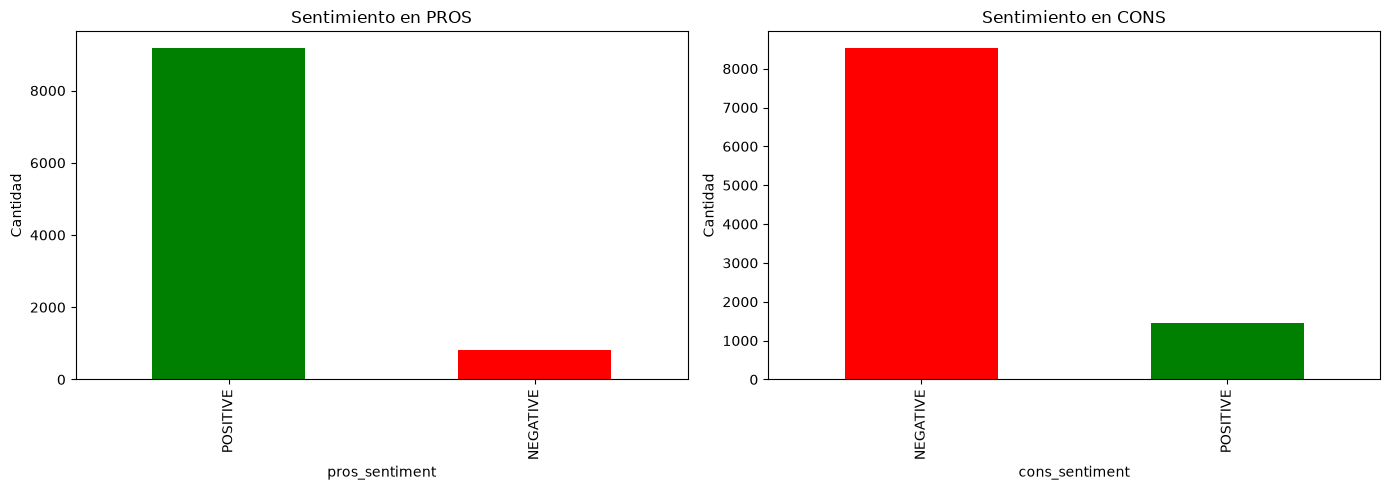

In [9]:
# --- Gráficos de sentimiento ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de sentimiento en pros
muestra['pros_sentiment'].value_counts().plot(
    kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Sentimiento en PROS')
axes[0].set_ylabel('Cantidad')

# Distribución de sentimiento en cons
muestra['cons_sentiment'].value_counts().plot(
    kind='bar', ax=axes[1], color=['red', 'green'])
axes[1].set_title('Sentimiento en CONS')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.savefig('../reports/figures/sentiment_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# --- Guardar muestra con sentimiento ---
muestra.to_csv('../data/nlp/glassdoor_sentiment.csv', index=False)
print(f'Datos con sentimiento guardados: {muestra.shape}')
print(f'Columnas: {muestra.columns.tolist()}')

Datos con sentimiento guardados: (10000, 24)
Columnas: ['firm', 'date_review', 'job_title', 'current', 'location', 'overall_rating', 'work_life_balance', 'culture_values', 'diversity_inclusion', 'career_opp', 'comp_benefits', 'senior_mgmt', 'recommend', 'ceo_approv', 'outlook', 'headline', 'pros', 'cons', 'pros_clean', 'cons_clean', 'pros_sentiment', 'pros_score', 'cons_sentiment', 'cons_score']
